# Day 4 — Building & Training a Neural Network with Keras

## Overview

In this notebook, we build and train a neural network using the TensorFlow/Keras Sequential API on the cleaned cardiovascular disease dataset.

The notebook follows the Day 4 hands-on lab:

1. Build a Keras Sequential neural network.
2. Compile and train the model using Adam and Binary Crossentropy.
3. Analyze training and validation loss and accuracy.
4. Add Batch Normalization and/or Dropout to reduce overfitting.
5. Evaluate the final model on the test set.
6. Compare the results with the Day 1 baseline model.

##  Import Libraries

We import the libraries required for data processing, visualization, preprocessing, and neural network development.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

##  Load the Cleaned Cardiovascular Dataset

The cleaned cardiovascular disease dataset is used as the main dataset for this experiment.

The target variable is cardio, where:

- 0 represents the negative class.
- 1 represents the positive class.

In [13]:
df = pd.read_csv("cardio_cleaned.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68742 entries, 0 to 68741
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68742 non-null  int64  
 1   gender       68742 non-null  int64  
 2   height       68742 non-null  int64  
 3   weight       68742 non-null  float64
 4   ap_hi        68742 non-null  int64  
 5   ap_lo        68742 non-null  int64  
 6   cholesterol  68742 non-null  int64  
 7   gluc         68742 non-null  int64  
 8   smoke        68742 non-null  int64  
 9   alco         68742 non-null  int64  
 10  active       68742 non-null  int64  
 11  cardio       68742 non-null  int64  
 12  age_years    68742 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 6.8 MB


In [14]:
print("Missing values:")
print(df.isnull().sum())
df.describe()

Missing values:
id             0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000
mean,49972.958555,1.348724,164.395042,74.123358,126.616494,81.382314,1.364799,1.226092,0.087996,0.053635,0.803381,0.494923,53.290967
std,28845.944439,0.476570,7.978866,14.306639,16.764166,9.676688,0.679027,0.572065,0.283291,0.225298,0.397445,0.499978,6.757142
min,0.000000,1.000000,100.000000,30.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.563313
25%,24997.250000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.342231
50%,50019.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.938398
75%,74865.750000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.381930
max,99999.000000,2.000000,207.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.922656


##  Separate Features and Target

The cardio column is the target variable.

All remaining columns are used as input features for the neural network.

In [18]:
X = df.drop(["cardio","id"], axis=1)
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68742, 11)
Target shape: (68742,)


## Target Distribution

We examine the distribution of the two target classes to determine whether the dataset is reasonably balanced.

In [16]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

cardio
0    34720
1    34022
Name: count, dtype: int64

cardio
0    0.505077
1    0.494923
Name: proportion, dtype: float64


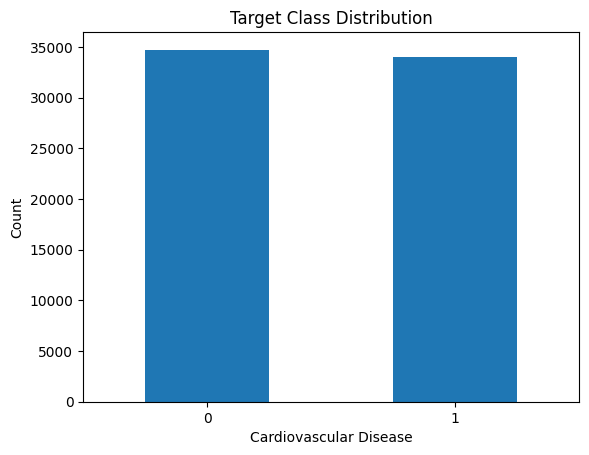

In [17]:
y.value_counts().plot(kind="bar")

plt.xlabel("Cardiovascular Disease")
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.xticks(rotation=0)
plt.show()

##  Train, Validation, and Test Split

The dataset is divided into three subsets:

- **Training set:** used to train the neural network.
- **Validation set:** used to monitor the model during training and diagnose overfitting.
- **Test set:** used for the final evaluation of the trained model.

Stratified splitting is used to preserve the target class distribution across the three subsets.

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (48119, 11)
Validation set: (10311, 11)
Test set: (10312, 11)


##  Feature Scaling

Neural networks generally perform better when input features have similar scales.

We use StandardScaler to standardize the input features.

The scaler is fitted only on the training data and then applied to the validation and test sets to prevent data leakage.

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



## Build the Baseline Neural Network

We build a feed-forward neural network using the Keras Sequential API.

The baseline architecture consists of:

- An input layer with 11 features.
- A hidden layer with 64 neurons and ReLU activation.
- A hidden layer with 32 neurons and ReLU activation.
- An output layer with one neuron and sigmoid activation.

Since the target variable is binary (cardio = 0 or 1), a single sigmoid output is appropriate.

In [25]:
baseline_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

##  Compile the Baseline Model

Before training, the model must be compiled.

We use:

- **Adam** as the optimizer to update the model weights.
- **Binary Crossentropy** as the loss function because this is a binary classification problem.
- **Accuracy** as the evaluation metric.

In [26]:
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Train the Baseline Model

The model is trained for 50 epochs using a batch size of 32.

The validation set is monitored during training to evaluate how well the model generalizes to unseen data.

In [30]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7446 - loss: 0.5248 - val_accuracy: 0.7249 - val_loss: 0.5541
Epoch 2/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7437 - loss: 0.5245 - val_accuracy: 0.7282 - val_loss: 0.5566
Epoch 3/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7439 - loss: 0.5243 - val_accuracy: 0.7292 - val_loss: 0.5541
Epoch 4/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7447 - loss: 0.5242 - val_accuracy: 0.7271 - val_loss: 0.5552
Epoch 5/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7458 - loss: 0.5238 - val_accuracy: 0.7267 - val_loss: 0.5555
Epoch 6/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7448 - loss: 0.5240 - val_accuracy: 0.7308 - val_loss: 0.5525
Epoch 7/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7447 - loss: 0.5235 - val_accuracy: 0.7268 - val_loss: 0.5537
Epoch 8/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7455 - loss: 0.5231 - 

##  Training and Validation Loss

The loss curves show how the model's error changes during training.

We compare the training loss with the validation loss to understand whether the model is learning effectively and to identify possible signs of overfitting.

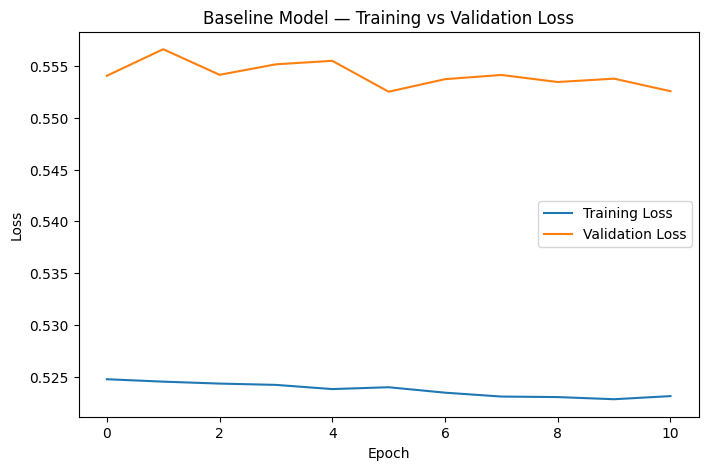

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model — Training vs Validation Loss")
plt.legend()
plt.show()

## Training and Validation Accuracy

The accuracy curves show how the classification performance changes during training.

We compare training and validation accuracy to determine whether the model generalizes well to unseen validation data.

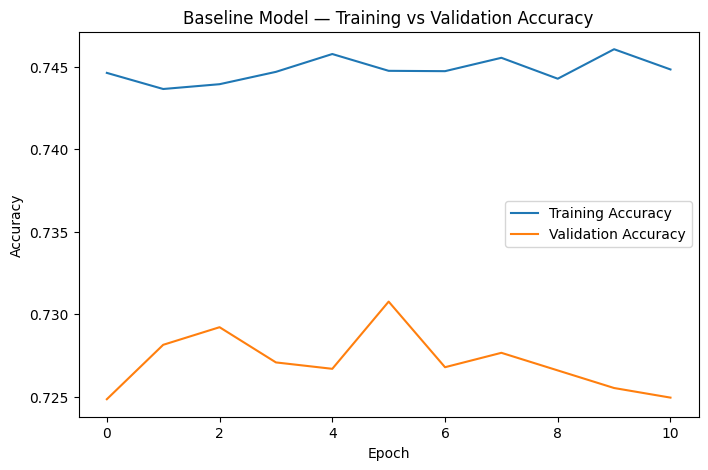

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model — Training vs Validation Accuracy")
plt.legend()
plt.show()

##  Baseline Model Diagnosis

The baseline model shows limited improvement during training.

- Training loss decreases slowly and then becomes relatively stable.
- Validation loss fluctuates around a similar range without a consistent improvement.
- Training accuracy remains around 74%–75%.
- Validation accuracy remains around 72%–73% and shows some fluctuations.
- The training and validation performance remain relatively close, indicating no strong signs of overfitting.

Overall, the baseline model shows limited learning and may benefit from additional techniques such as Batch Normalization and Dropout.

##  Build an Improved Neural Network

The baseline model showed limited improvement during training.

To improve training stability and reduce the risk of overfitting, we add Batch Normalization and Dropout to the neural network.

- Batch Normalization helps stabilize the training process.
- Dropout acts as a regularization technique by randomly disabling a fraction of neurons during training.

In [34]:
improved_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])
improved_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

##  Compile the Improved Model

The improved model is compiled using the same optimizer, loss function, and evaluation metric as the baseline model.

- **Adam** is used as the optimizer.
- **Binary Crossentropy** is used as the loss function for binary classification.
- **Accuracy** is used as the main metric.

In [35]:
improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Train the Improved Model

The improved model is trained using the same training and validation sets, number of epochs, and batch size as the baseline model.

This allows us to make a fair comparison between the two models.

In [36]:
early_stopping_improved = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_improved],
    verbose=1
)

Epoch 1/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7003 - loss: 0.5970 - val_accuracy: 0.7318 - val_loss: 0.5518
Epoch 2/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7227 - loss: 0.5629 - val_accuracy: 0.7297 - val_loss: 0.5477
Epoch 3/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7271 - loss: 0.5583 - val_accuracy: 0.7327 - val_loss: 0.5465
Epoch 4/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7292 - loss: 0.5562 - val_accuracy: 0.7301 - val_loss: 0.5461
Epoch 5/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7277 - loss: 0.5563 - val_accuracy: 0.7326 - val_loss: 0.5458
Epoch 6/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7281 - loss: 0.5533 - val_accuracy: 0.7348 - val_loss: 0.5439
Epoch 7/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7290 - loss: 0.5534 - val_accuracy: 0.7326 - val_loss: 0.5432
Epoch 8/50
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7307 - loss: 0.5529 -

##  Improved Model — Training and Validation Loss

The loss curves are used to evaluate the learning behavior of the improved model and compare it with the baseline model.

We examine whether Batch Normalization and Dropout helped improve the validation performance and training stability.

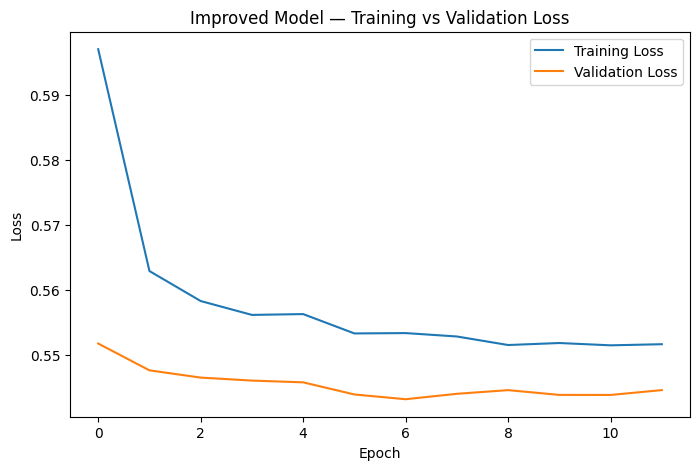

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_improved.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_improved.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Model — Training vs Validation Loss")
plt.legend()
plt.show()

##  Improved Model — Loss Diagnosis

The improved model shows a gradual decrease in training loss, followed by a more stable learning pattern.

The validation loss decreases slightly at the beginning and then remains relatively stable.

Compared with the baseline model, the validation loss shows less fluctuation, indicating a more stable training process after adding Batch Normalization and Dropout.

There are no strong signs of overfitting, as the validation loss does not show a clear and sustained increase while the training loss continues to decrease.

##  Improved Model — Training and Validation Accuracy

The accuracy curves show how the classification performance changes during training.

We compare training and validation accuracy to determine whether the improved model generalizes better than the baseline model.

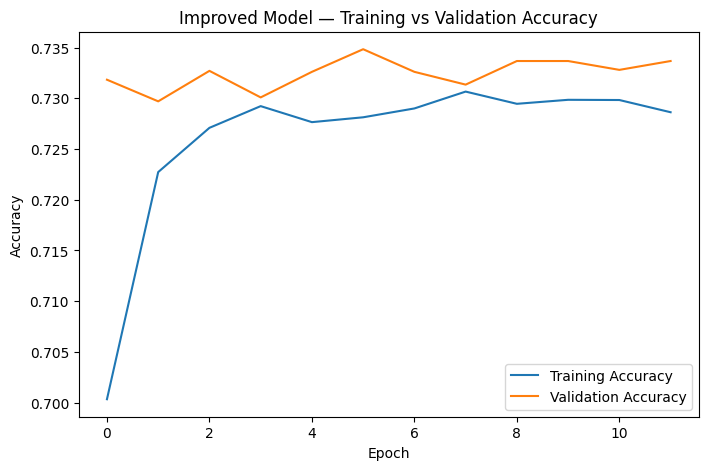

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_improved.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_improved.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Model — Training vs Validation Accuracy")
plt.legend()
plt.show()

##  Improved Model — Accuracy Diagnosis

The training accuracy gradually improves from approximately 70% to around 73%, followed by small fluctuations and relative stability.

The validation accuracy starts at approximately 73.2%, reaches a peak of about 73.5%, and then fluctuates slightly before becoming relatively stable.

The validation accuracy remains close to or slightly higher than the training accuracy. This can occur because Dropout is active during training but is not applied during validation.

Overall, the improved model shows a more stable learning pattern, with no strong signs of overfitting.

## Evaluate the Baseline Model

The baseline model is evaluated on the unseen test set.

The test set was not used during training, allowing us to measure how well the model generalizes to unseen data.

In [39]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Baseline Test Loss:", baseline_test_loss)
print("Baseline Test Accuracy:", baseline_test_accuracy)

Baseline Test Loss: 0.5577430725097656
Baseline Test Accuracy: 0.7297323346138


## Evaluate the Improved Model

The improved model is evaluated on the same unseen test set.

Using the same test set allows us to make a fair comparison between the baseline and improved models.

In [40]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

Improved Test Loss: 0.5464217066764832
Improved Test Accuracy: 0.7339992523193359


## Test Set Evaluation

The improved model achieved better performance on the unseen test set compared with the baseline model.

- The test loss decreased from approximately 0.558 to 0.546.
- The test accuracy increased from approximately 72.97% to 73.40%.

This indicates that adding Batch Normalization and Dropout provided a small improvement in the model's generalization performance.

However, the improvement in accuracy is relatively small, so the additional regularization did not produce a major performance increase.

In [42]:
baseline_probs = baseline_model.predict(
    X_test_scaled,
    verbose=0
)

improved_probs = improved_model.predict(
    X_test_scaled,
    verbose=0
)

baseline_preds = (baseline_probs >= 0.5).astype(int).ravel()
improved_preds = (improved_probs >= 0.5).astype(int).ravel()

In [43]:
print("Baseline Model")
print(classification_report(y_test, baseline_preds))

print("\nImproved Model")
print(classification_report(y_test, improved_preds))

Baseline Model
              precision    recall  f1-score   support

           0       0.72      0.75      0.74      5208
           1       0.74      0.71      0.72      5104

    accuracy                           0.73     10312
   macro avg       0.73      0.73      0.73     10312
weighted avg       0.73      0.73      0.73     10312


Improved Model
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      5208
           1       0.74      0.71      0.73      5104

    accuracy                           0.73     10312
   macro avg       0.73      0.73      0.73     10312
weighted avg       0.73      0.73      0.73     10312



##  Model Comparison

The baseline and improved neural networks are compared using Accuracy, Precision, Recall, and F1-score on the unseen test set.

The improved model shows a small improvement in overall classification performance compared with the baseline model.

In [44]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Neural Network",
        "Improved Neural Network"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, improved_preds)
    ],
    "Precision": [
        precision_score(y_test, baseline_preds),
        precision_score(y_test, improved_preds)
    ],
    "Recall": [
        recall_score(y_test, baseline_preds),
        recall_score(y_test, improved_preds)
    ],
    "F1-Score": [
        f1_score(y_test, baseline_preds),
        f1_score(y_test, improved_preds)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Neural Network,0.729732,0.737252,0.705329,0.720937
1,Improved Neural Network,0.733999,0.739890,0.713362,0.726384


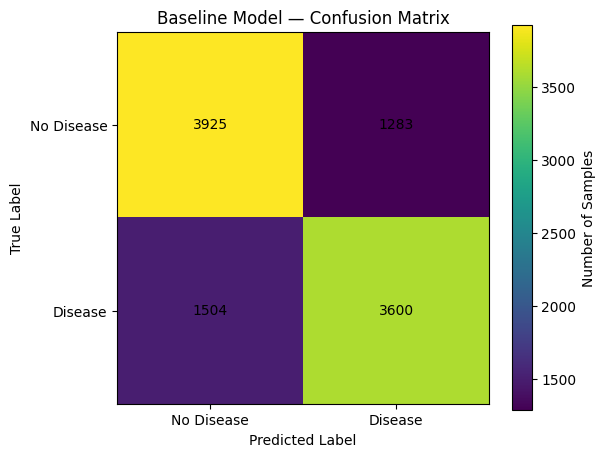

In [48]:
baseline_cm = confusion_matrix(y_test, baseline_preds)
improved_cm = confusion_matrix(y_test, improved_preds)

plt.figure(figsize=(6, 5))

plt.imshow(baseline_cm, cmap="viridis")

plt.colorbar(label="Number of Samples")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.yticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline Model — Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            baseline_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

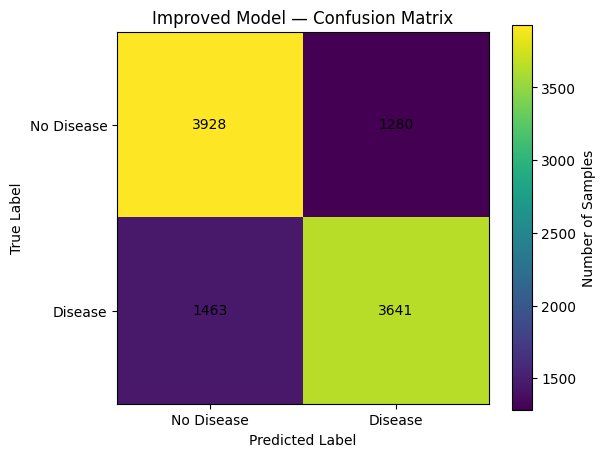

In [49]:
plt.figure(figsize=(6, 5))

plt.imshow(improved_cm, cmap="viridis")

plt.colorbar(label="Number of Samples")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.yticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Improved Model — Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            improved_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

##  Final Conclusion

A neural network was successfully built and trained using the TensorFlow/Keras Sequential API for cardiovascular disease classification.

The baseline model achieved a test accuracy of approximately 72.97%.

After adding Batch Normalization and Dropout, the improved model achieved a test accuracy of approximately 73.40% and a lower test loss.

This represents a small improvement of approximately 0.43 percentage points in test accuracy.

The training and validation curves showed relatively stable behavior without strong signs of overfitting.

Overall, Batch Normalization and Dropout slightly improved the model's generalization performance, although the improvement was limited.